In [3]:
%pip install "numpy>=1.25,<2.0"
!pip install mlxtend

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.0/14.0 MB 24.0 MB/s eta 0:00:001m24.4 MB/s eta 0:00:01
  Attempting uninstall: numpy
    Found existing installation: numpy 2.4.6
    Uninstalling numpy-2.4.6:
      Successfully uninstalled numpy-2.4.6
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tables 3.8.0 requires blosc2~=2.0.0, which is not installed.
tables 3.8.0 requires cython>=0.29.21, which is not installed.
gensim 4.3.0 requires FuzzyTM>=0.4.0, which is not installed.
numba 0.57.0 requires numpy<1.25,>=1.21, but you have numpy 1.26.4 which is incompatible.
mlxtend 0.25.0 requires numpy>=2.3.5, but you have numpy 1.26.4 which is incompatible.

[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
  Using cached numpy-2.4.6-cp311-

In [4]:
import numpy as np
import pandas as pd
from mlxtend.frequent_patterns import apriori, association_rules
import networkx as nx
%config InlineBackend.figure_format = 'retina'
import matplotlib.pyplot as plt

In [5]:
# Set random seed for reproducibility
np.random.seed(42)

# Define item names
items = ['Bread', 'Butter', 'Milk', 'Cheese', 'Eggs', 'Apples', 'Bananas', 'Coffee', 'Tea', 'Sugar']

# Create a DataFrame with 1000 transactions and 10 items
n_transactions = 1000
n_items = len(items)

# Generate random 0s and 1s to simulate items purchased in transactions
# 0 means the item was not purchased, 1 means the item was purchased
data = np.random.randint(2, size=(n_transactions, n_items))

# Create a DataFrame with random transactions
df = pd.DataFrame(data, columns=items)

# Display the first few rows of the dataset
print(df.head())

   Bread  Butter  Milk  Cheese  Eggs  Apples  Bananas  Coffee  Tea  Sugar
0      0       1     0       0     0       1        0       0    0      1
1      0       0     0       0     1       0        1       1    1      0
2      1       0     1       1     1       1        1       1    1      1
3      0       0     1       1     1       0        1       0    0      0
4      0       0     1       1     1       1        1       0    1      1


In [6]:
# Generate frequent itemsets with a support threshold of 0.05 (5%)
frequent_itemsets = apriori(df, min_support=0.2, use_colnames=True)

# Generate association rules with confidence threshold of 0.1
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1)

/Users/yanhaixiong/anaconda3/lib/python3.11/site-packages/mlxtend/frequent_patterns/fpcommon.py:175: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


In [8]:
frequent_itemsets.head()

,support,itemsets
0,0.507,frozenset({Bread})
1,0.491,frozenset({Butter})
2,0.482,frozenset({Milk})
3,0.501,frozenset({Cheese})
4,0.498,frozenset({Eggs})


In [10]:
# representativity: Coverage/reliability of the rule under incomplete data (Usually 1.0 for ordinary complete transaction data)
# leverage P(X,Y)-P(X)P(Y) Difference between observed co-occurrence and independence
# conviction \(\frac{1-P(Y)}{1-P(Y\mid X)}\) Measures how strongly \(X\) implies \(Y\), emphasizing violations
# zhangs_metric Association measure from \(-1\) to \(1\) \(>0\): positive association; \(0\): independence; \(<0\): negative
# jaccard \(\frac{P(X,Y)}{P(X)+P(Y)-P(X,Y)}\) Similarity/overlap between transactions containing \(X\) and Y
# certainty Improvement in certainty of \(Y\) given \(X\) Higher positive values indicate stronger predictive association
# ulczynski Average of \(P(Y\mid X)\) and \(P(X\mid Y)\) Symmetric measure of association
rules.head()

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,frozenset({Bread}),frozenset({Butter}),0.507,0.491,0.250,0.493097,1.004270,1.0,0.001063,1.004136,0.008625,0.334225,0.004119,0.501131
1,frozenset({Butter}),frozenset({Bread}),0.491,0.507,0.250,0.509165,1.004270,1.0,0.001063,1.004411,0.008354,0.334225,0.004391,0.501131
2,frozenset({Milk}),frozenset({Bread}),0.482,0.507,0.262,0.543568,1.072127,1.0,0.017626,1.080118,0.129874,0.360385,0.074175,0.530167
3,frozenset({Bread}),frozenset({Milk}),0.507,0.482,0.262,0.516765,1.072127,1.0,0.017626,1.071943,0.136460,0.360385,0.067114,0.530167
4,frozenset({Bread}),frozenset({Apples}),0.507,0.481,0.261,0.514793,1.070256,1.0,0.017133,1.069646,0.133151,0.359010,0.065112,0.528706


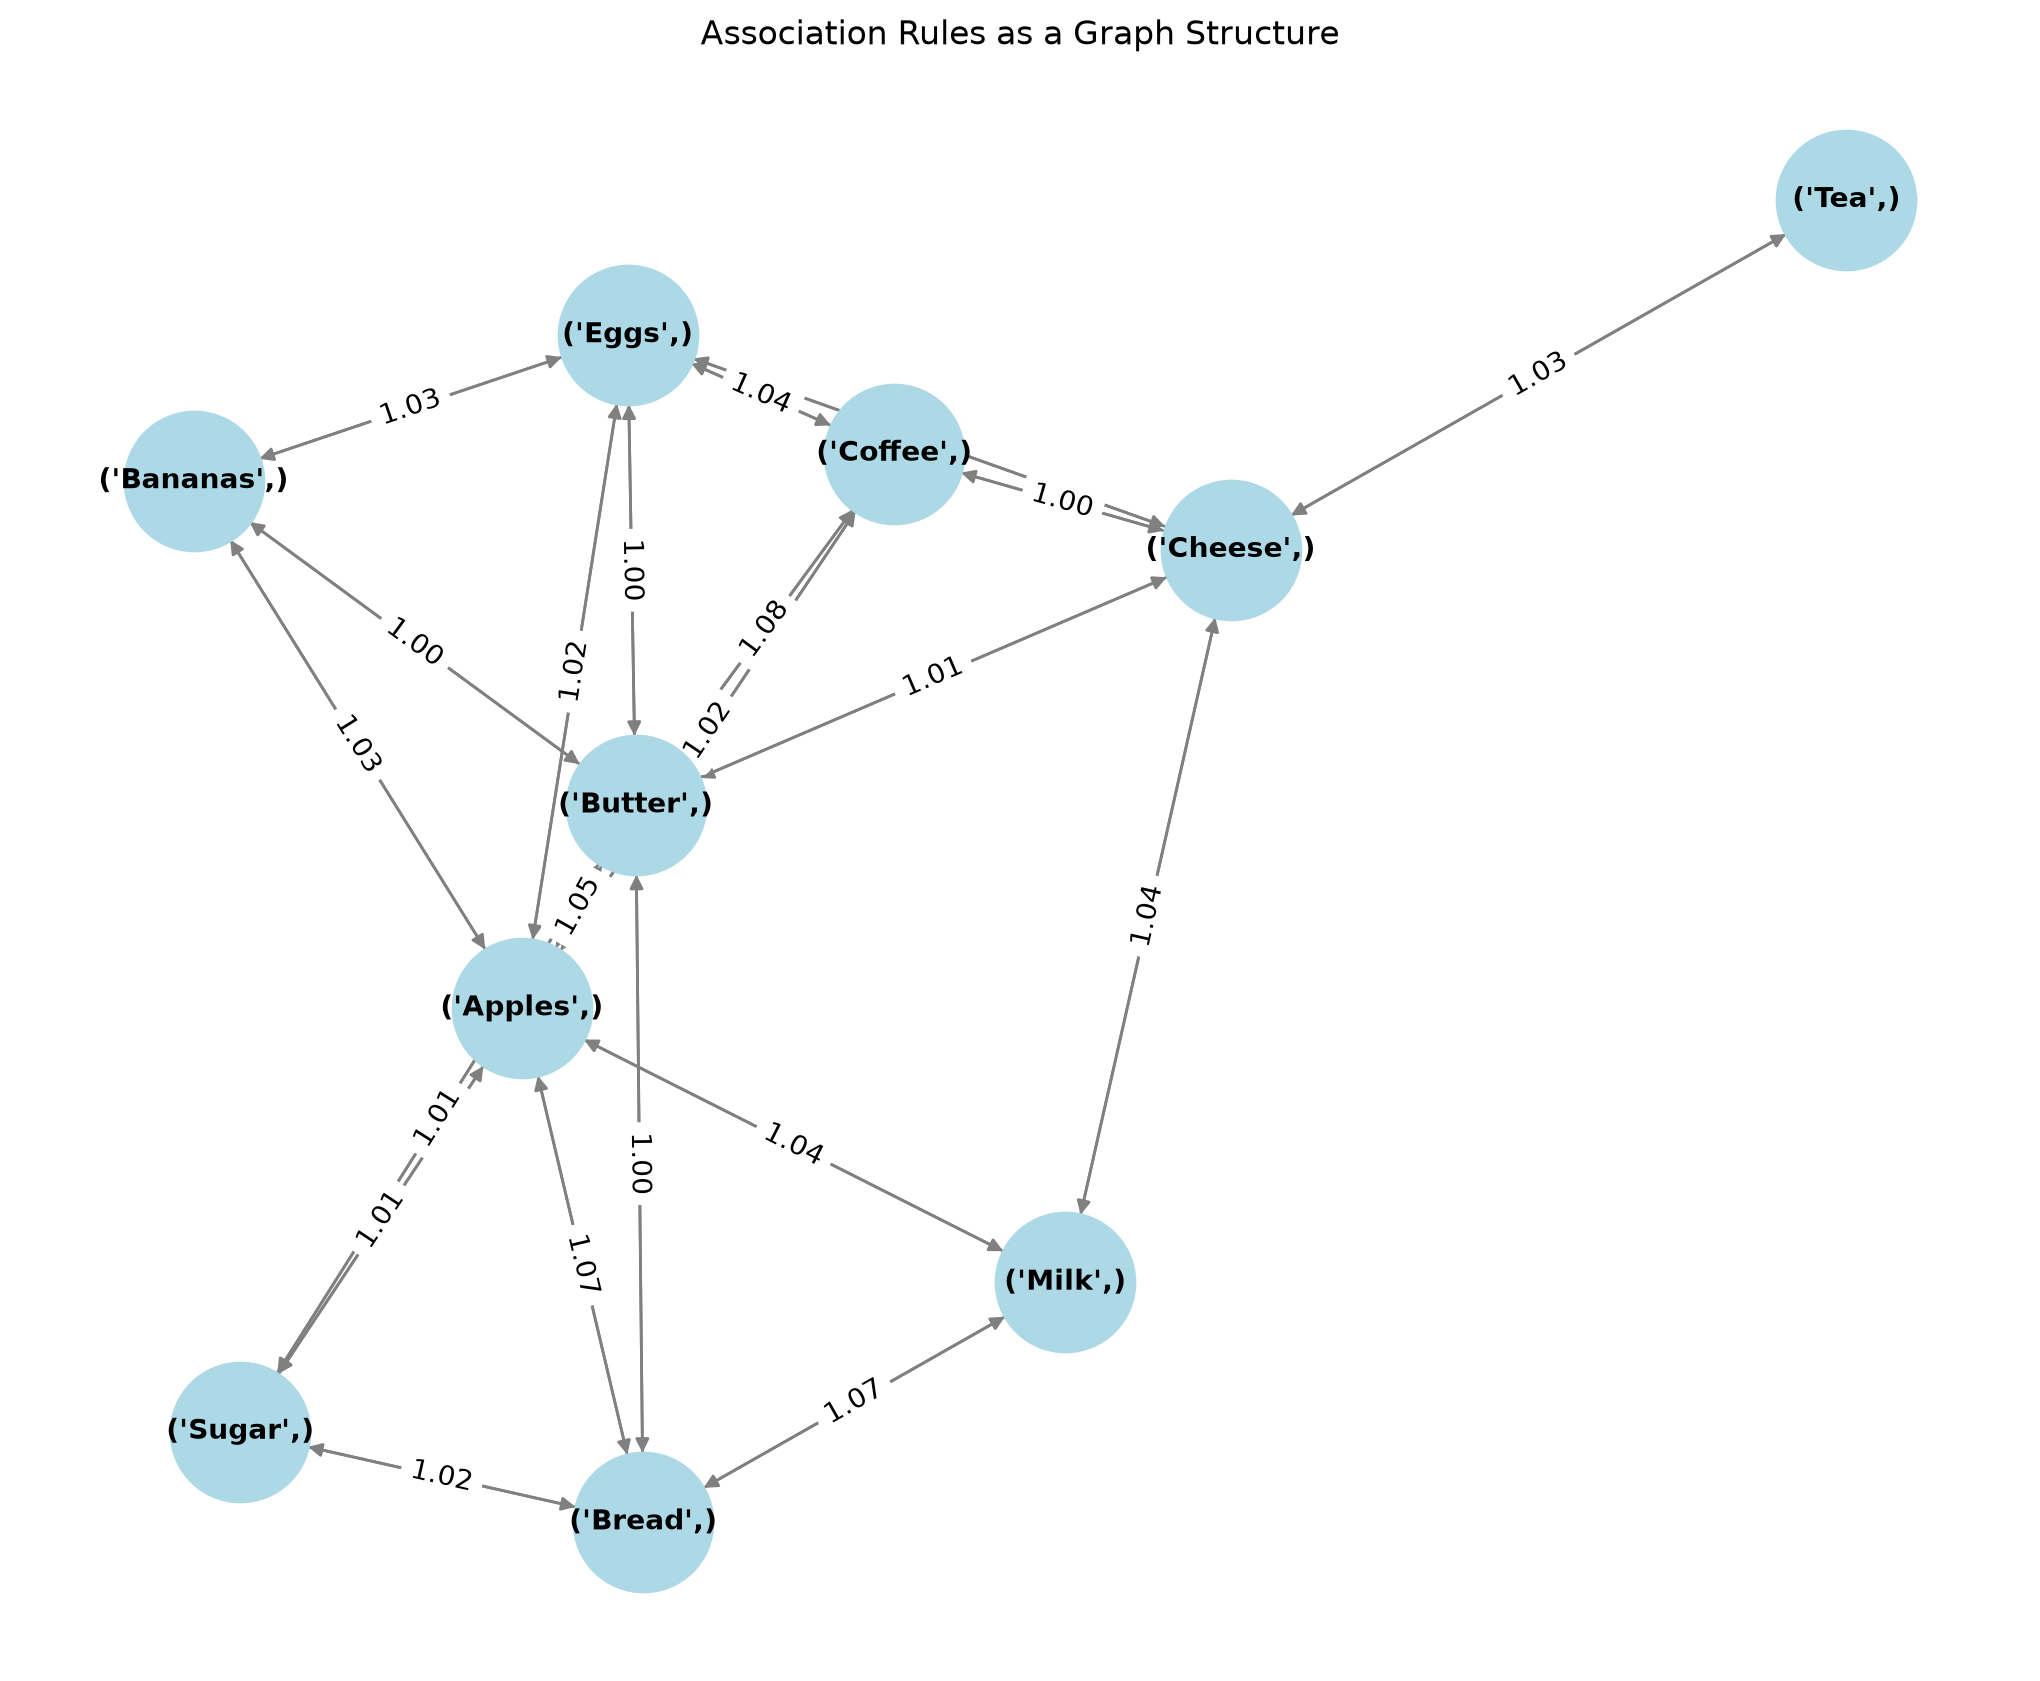

In [12]:
# Create a directed graph
G = nx.DiGraph()

# Add edges to the graph (from antecedents to consequents)
for _, rule in rules.iterrows():
    antecedents = tuple(rule['antecedents'])
    consequents = tuple(rule['consequents'])
    G.add_edges_from([(antecedents, consequents)], weight=rule['lift'])

# Plot the graph
plt.figure(figsize=(10, 8))

# Define node positions
pos = nx.spring_layout(G, seed=10)

# Draw the nodes and edges
nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=2500, font_size=10, font_weight='bold', edge_color='gray')

# Draw edge labels for lift values
edge_labels = {(tuple(rule['antecedents']), tuple(rule['consequents'])): f"{rule['lift']:.2f}" for _, rule in rules.iterrows()}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

plt.title('Association Rules as a Graph Structure')
plt.show()

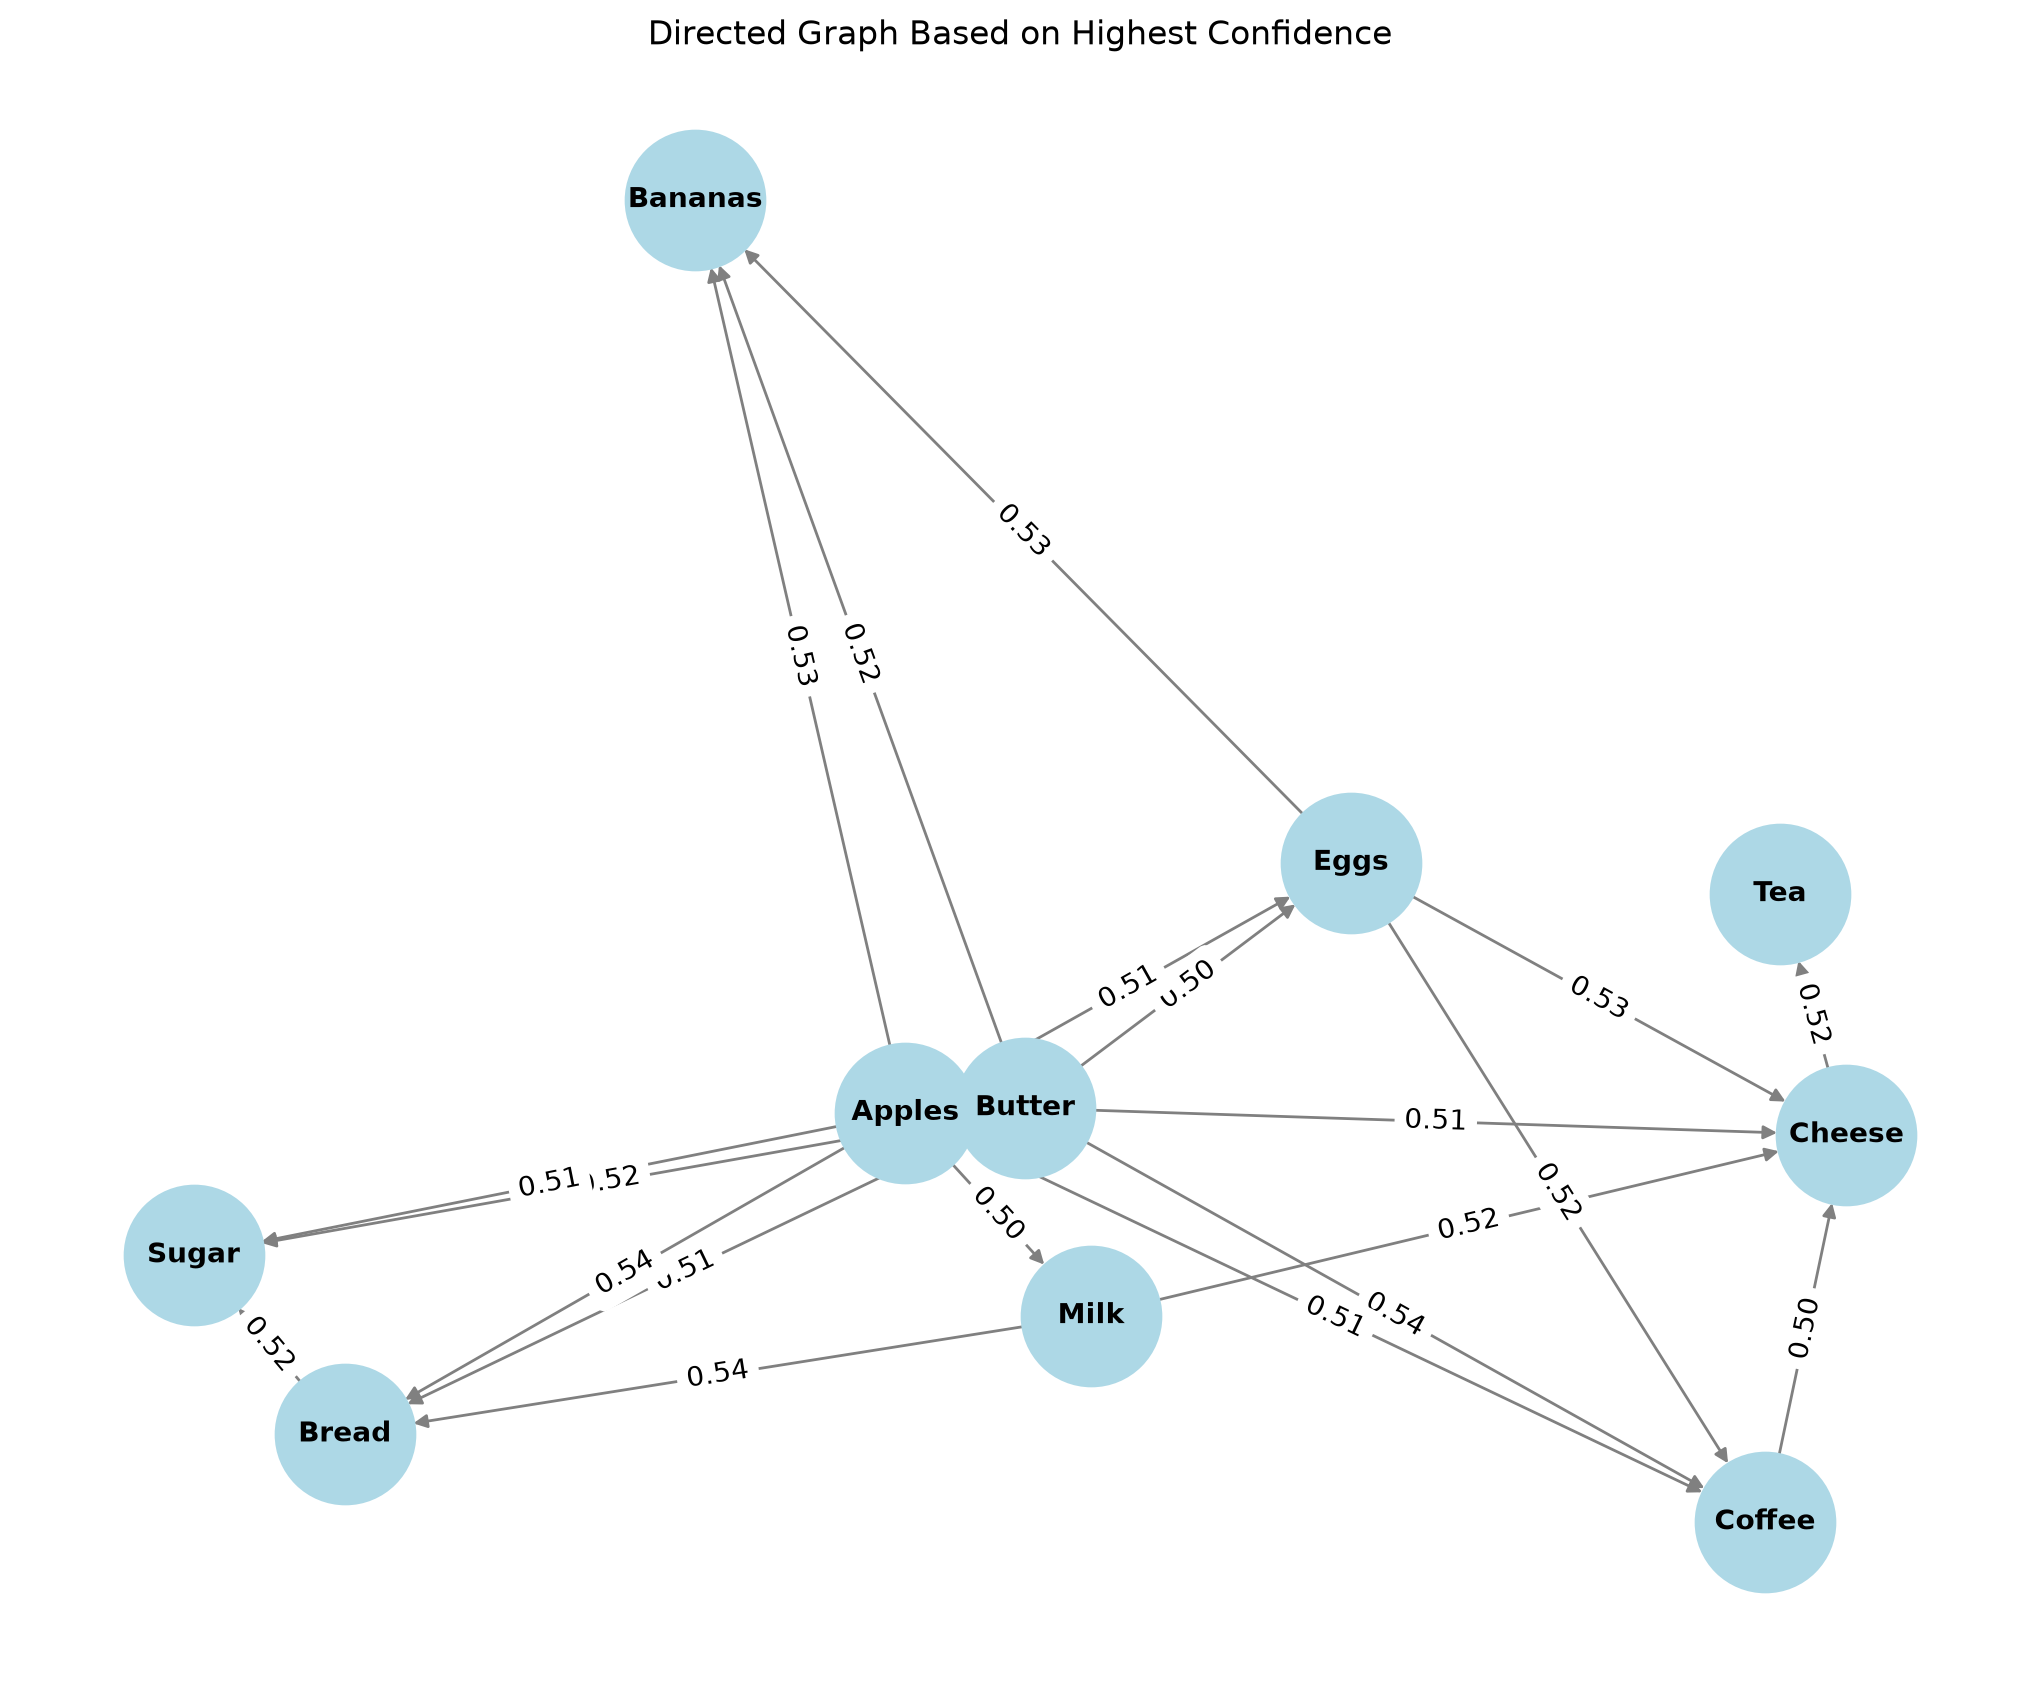

In [15]:
# show the graph structure

G = nx.DiGraph()

# We only want pairs of items (i.e., antecedents and consequents that are of length 1)
for _, rule in rules.iterrows():
    antecedents = tuple(rule['antecedents'])
    consequents = tuple(rule['consequents'])

    # Ensure both antecedents and consequents are single items
    if len(antecedents) == 1 and len(consequents) == 1:
        antecedent = list(antecedents)[0]
        consequent = list(consequents)[0]

        # Check if we already have an edge in the opposite direction
        if G.has_edge(consequent, antecedent):
            # Get the current confidence of the opposite direction
            opposite_confidence = G[consequent][antecedent]['weight']

            # Compare the confidences and retain the edge with the higher confidence (not lift!)
            if rule['confidence'] > opposite_confidence:
                G.remove_edge(consequent, antecedent)
                G.add_edge(antecedent, consequent, weight=rule['confidence'])
        else:
            # Add a directed edge from antecedent to consequent
            G.add_edge(antecedent, consequent, weight=rule['confidence'])

# Step 5: Visualize the directed graph
plt.figure(figsize=(10, 8))

# Define node positions
pos = nx.spring_layout(G, seed=100)

# Draw the nodes and edges
nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=2500, font_size=10, font_weight='bold', edge_color='gray')

# Draw edge labels for confidence values
edge_labels = {(u, v): f"{d['weight']:.2f}" for u, v, d in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

plt.title('Directed Graph Based on Highest Confidence')
plt.show()

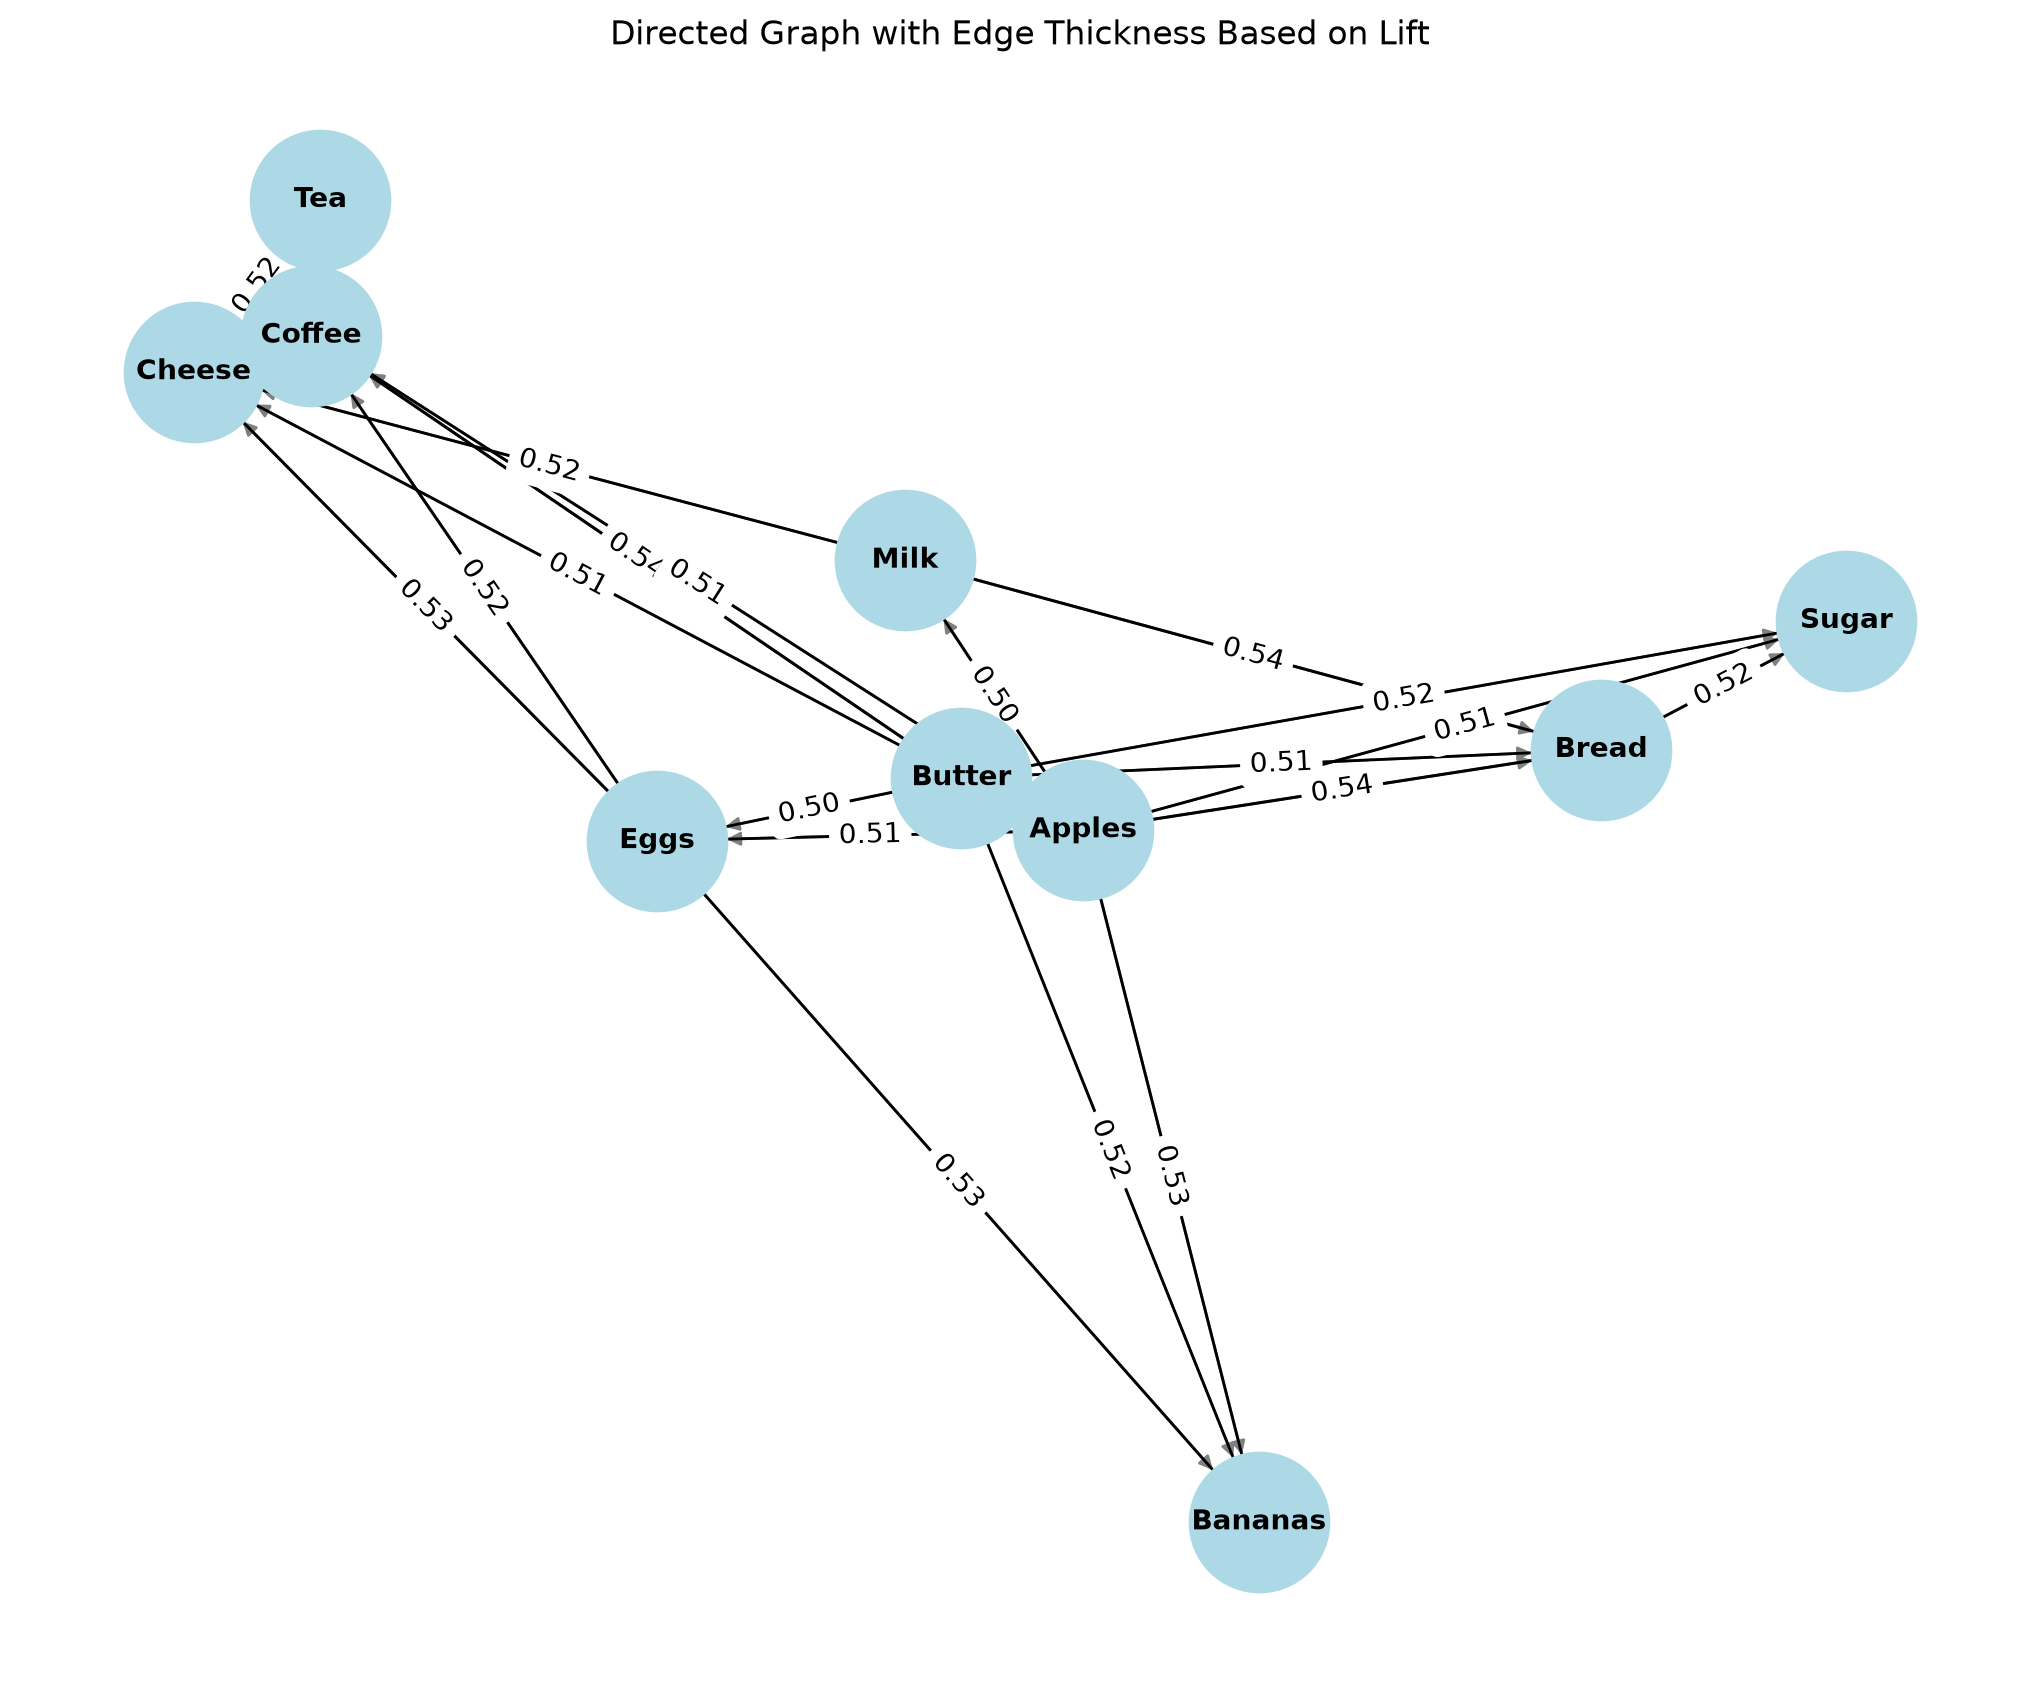

In [18]:
G = nx.DiGraph()

# We only want pairs of items (i.e., antecedents and consequents that are of length 1)
for _, rule in rules.iterrows():
    antecedents = tuple(rule['antecedents'])
    consequents = tuple(rule['consequents'])

    # Ensure both antecedents and consequents are single items
    if len(antecedents) == 1 and len(consequents) == 1:
        antecedent = list(antecedents)[0]
        consequent = list(consequents)[0]

        # Check if we already have an edge in the opposite direction
        if G.has_edge(consequent, antecedent):
            # Get the current confidence of the opposite direction
            opposite_confidence = G[consequent][antecedent]['weight']

            # Compare the confidences and retain the edge with the higher confidence
            if rule['confidence'] > opposite_confidence:
                G.remove_edge(consequent, antecedent)
                G.add_edge(antecedent, consequent, weight=rule['confidence'], lift=rule['lift'])
        else:
            # Add a directed edge from antecedent to consequent
            G.add_edge(antecedent, consequent, weight=rule['confidence'], lift=rule['lift'])

# Step 5: Visualize the directed graph with edge thickness based on lift
plt.figure(figsize=(10, 8))

# Define node positions
pos = nx.spring_layout(G, seed=400)

# Draw the nodes
nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=2500, font_size=10, font_weight='bold', edge_color='gray')

# Draw the edges with thickness proportional to lift
edge_lifts = [d['lift'] for _, _, d in G.edges(data=True)]
nx.draw_networkx_edges(G, pos, width=[1 * lift for lift in edge_lifts], edge_color='black')

# Draw edge labels for confidence values
edge_labels = {(u, v): f"{d['weight']:.2f}" for u, v, d in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

plt.title('Directed Graph with Edge Thickness Based on Lift')
plt.show()

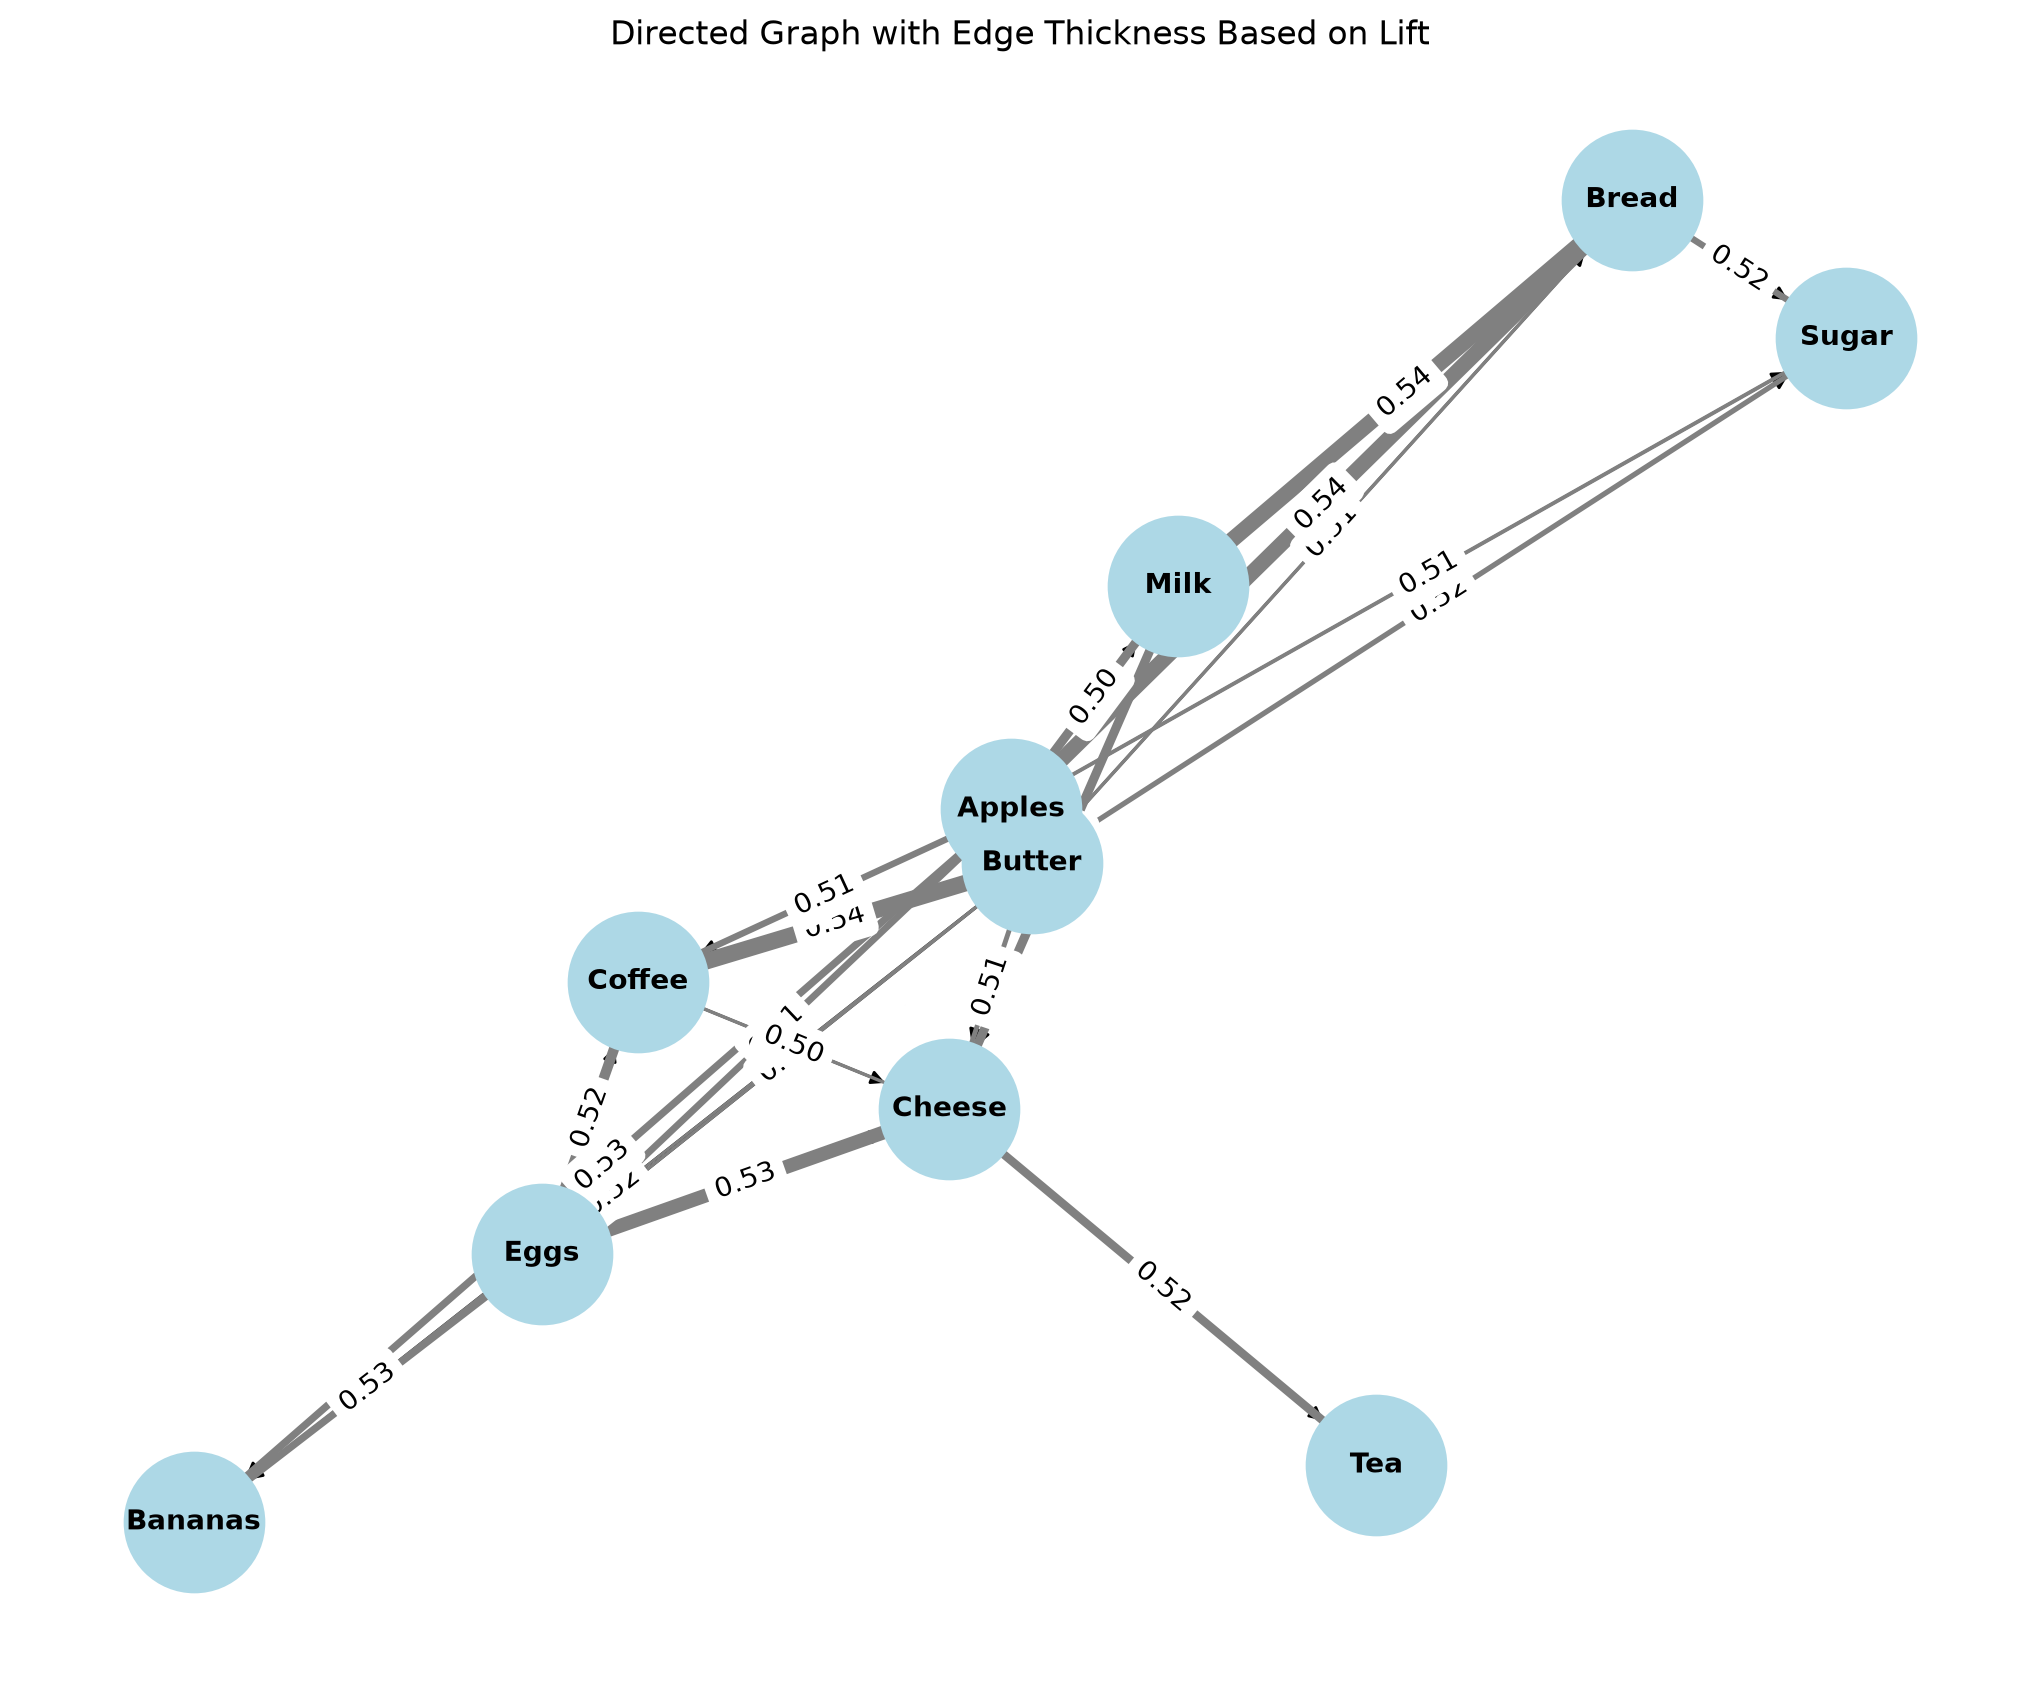

In [19]:
G = nx.DiGraph()

# We only want pairs of items (i.e., antecedents and consequents that are of length 1)
for _, rule in rules.iterrows():
    antecedents = tuple(rule['antecedents'])
    consequents = tuple(rule['consequents'])

    # Ensure both antecedents and consequents are single items
    if len(antecedents) == 1 and len(consequents) == 1:
        antecedent = list(antecedents)[0]
        consequent = list(consequents)[0]

        # Check if we already have an edge in the opposite direction
        if G.has_edge(consequent, antecedent):
            # Get the current confidence of the opposite direction
            opposite_confidence = G[consequent][antecedent]['weight']

            # Compare the confidences and retain the edge with the higher confidence
            if rule['confidence'] > opposite_confidence:
                G.remove_edge(consequent, antecedent)
                G.add_edge(antecedent, consequent, weight=rule['confidence'], lift=rule['lift'])
        else:
            # Add a directed edge from antecedent to consequent
            G.add_edge(antecedent, consequent, weight=rule['confidence'], lift=rule['lift'])

# Step 5: Visualize the directed graph with thicker edges for higher lift
plt.figure(figsize=(10, 8))

# Define node positions
pos = nx.spring_layout(G, seed=42)

# Get edge weights (confidence) and lift values for each edge
edges, weights = zip(*nx.get_edge_attributes(G, 'weight').items())
lifts = nx.get_edge_attributes(G, 'lift').values()

# Normalize the lift values to use for edge thickness (you can adjust the scaling factor)
min_lift = min(lifts)
max_lift = max(lifts)
edge_thickness = [(5 * (lift - min_lift) / (max_lift - min_lift + 1e-6)) + 1 for lift in lifts]

# Draw the nodes and edges
nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=2500, font_size=10, font_weight='bold')

# Draw edges with thickness based on the lift values
nx.draw_networkx_edges(G, pos, edgelist=edges, width=edge_thickness, edge_color='gray')

# Draw edge labels for confidence values
edge_labels = {(u, v): f"{d['weight']:.2f}" for u, v, d in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

plt.title('Directed Graph with Edge Thickness Based on Lift')
plt.show()